# Lecture 2: Univariate Data: Summary Statistics,
Distributions & Plots, Normal Distribution

# A.1 Import libraries

In [20]:
library(dplyr)
library(ggplot2)
library(ggthemes)

## Outline

1. [Review and context](#Section_1)
2. [Visualizing data](#Section_2)
3. [Describing distributions](#Section_3)

<a id='Section_1'></a>
## 1. Review and context

## 1.1. Histogram of population: mean=0, std =1

### 1.1.1 Generate data

- `function:` rnorm()
    - Generates observations in the normal distribution

In [2]:
#Generates 10 observations in the normal distribution
# Mean = 0
# Standard devation= 1
rnorm(10, mean = 0, sd = 1)

[1] 0.27053231 0.98624748 0.59169800 0.32924931 0.07495899 0.81872292
 [7] 1.28647323 1.01238478 0.19501671 0.48677285

#### 1.1.1.1 Save data: REMEMBER IN R WE MUST USE THE = SIGN TO SAVE A NEW OBJECT

In [3]:
normal_data = rnorm(1000, mean = 0, sd = 1)

### 1.1.2 Graph data
- `function:` hist(DATA_NAME)
    - Plots histogram


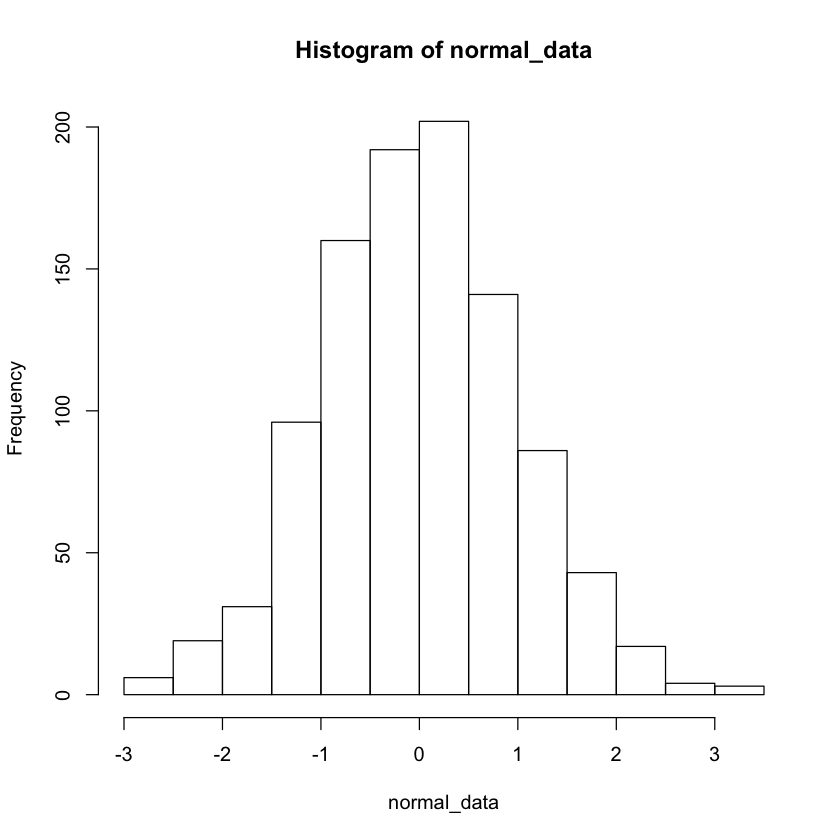

In [4]:
hist(normal_data)

## 1.2 Histogram of population and sample

### 1.2.1 Sample with random draws from population
- `function:` sample(DATA_NAME, "# of data")
    - Plots histogram

In [5]:
sample_data = sample(normal_data, 300)

### 1.2.2 Graph data

In [6]:
normal_data_ggformat = as_tibble(normal_data)
sample_data_ggformat = as_tibble(sample_data)

Warning message:
“Calling `as_tibble()` on a vector is discouraged, because the behavior is likely to change in the future. Use `tibble::enframe(name = NULL)` instead.
This warning is displayed once per session.”

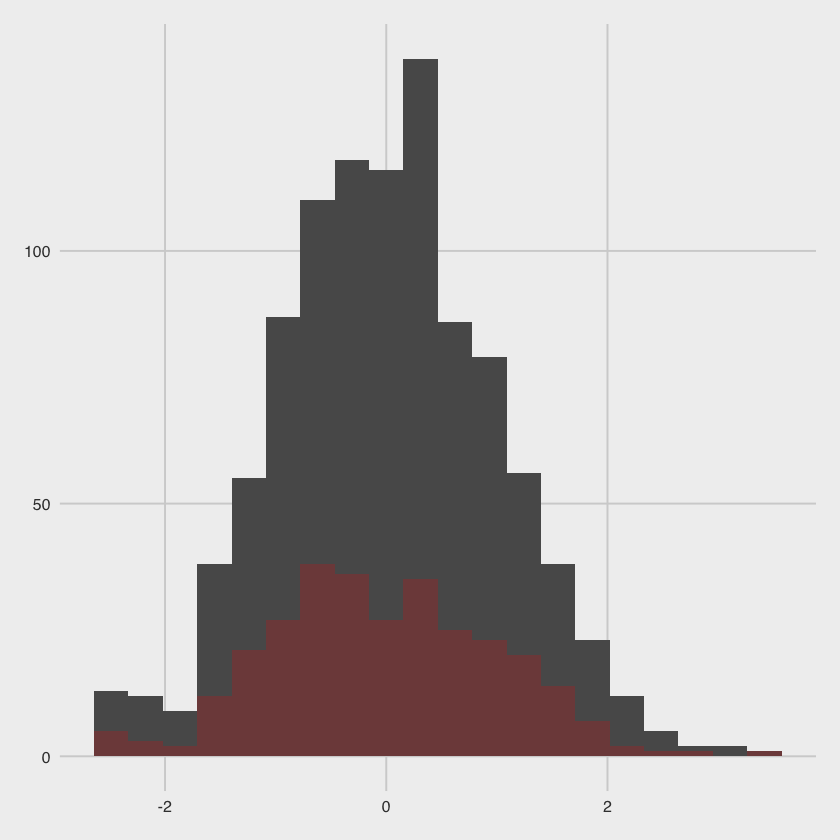

In [7]:
normal_data_ggformat %>% #Plot normal_data
ggplot(aes(x=value))+ #Selects data column by name
geom_histogram(bins=20)+ #Sets the bin number 
geom_histogram(data=sample_data_ggformat, bins =20, fill = "red", alpha = 0.2)+ #Plot sample data
scale_color_fivethirtyeight("cyl") + #Sets the plot theme
theme_fivethirtyeight() #Sets the plot theme

<a id='Section_2'></a>
## 2. Visualizing data

## 2.1 Scatter plots

### 2.1.1 Download data from online csv

In [8]:
#Download data from github
covid_data_url = "https://raw.githubusercontent.com/corybaird/Development_economics/master/TA_Sessions/R/W3_ggplot/global_covid.csv"
#Download
covid = read.csv(covid_data_url)

### 2.1.2 Use head function to look at first two rows
- `function:` head(DATA_NAME, #_ROWS)
    - Shows only specific number of rows
    - Default is 5

In [9]:
covid %>% head(2)

X,name,confirm,suspect,dead,deadRate,showRate,heal,healRate,showHeal
1,China,83039,88,3340,4.02,FALSE,77361,93.16,TRUE
2,United States,143071,0,2513,1.76,FALSE,4856,3.39,FALSE


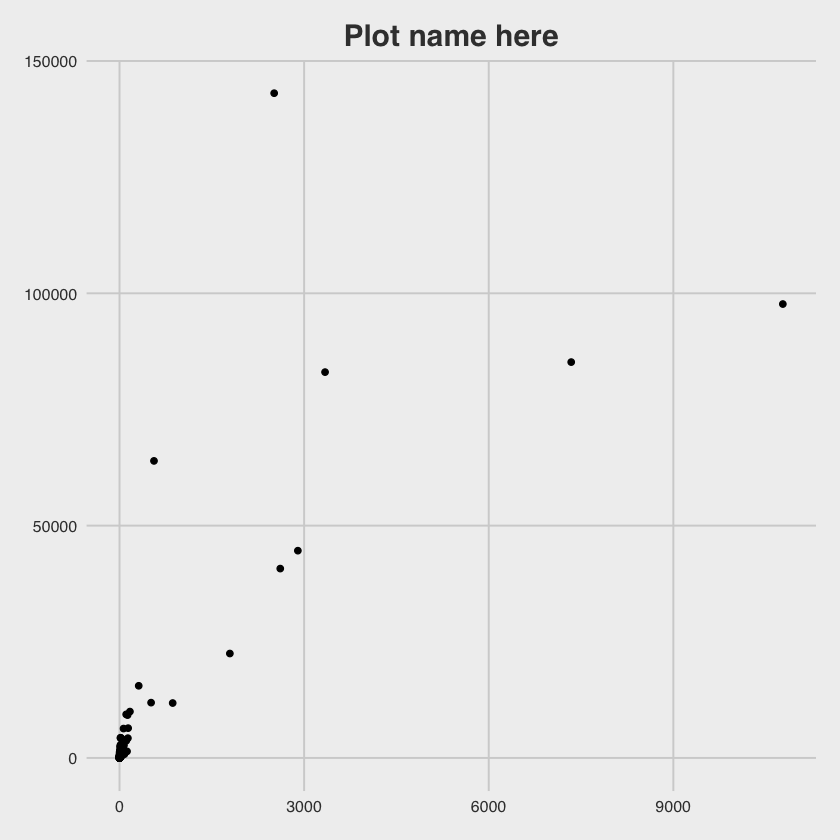

In [10]:
ggplot(covid, aes(x = dead, y = confirm)) + #Chooses the data by column name
geom_point()+ #Plots the points
ggtitle('Plot name here')+ #Plot title
scale_color_fivethirtyeight("cyl") + #Sets the plot theme
theme_fivethirtyeight()+theme(plot.title = element_text(hjust = 0.5)) #Sets the plot theme

## 2.2 Histogram with varying bin size 
- Same data but it looks vastly different based on bin size

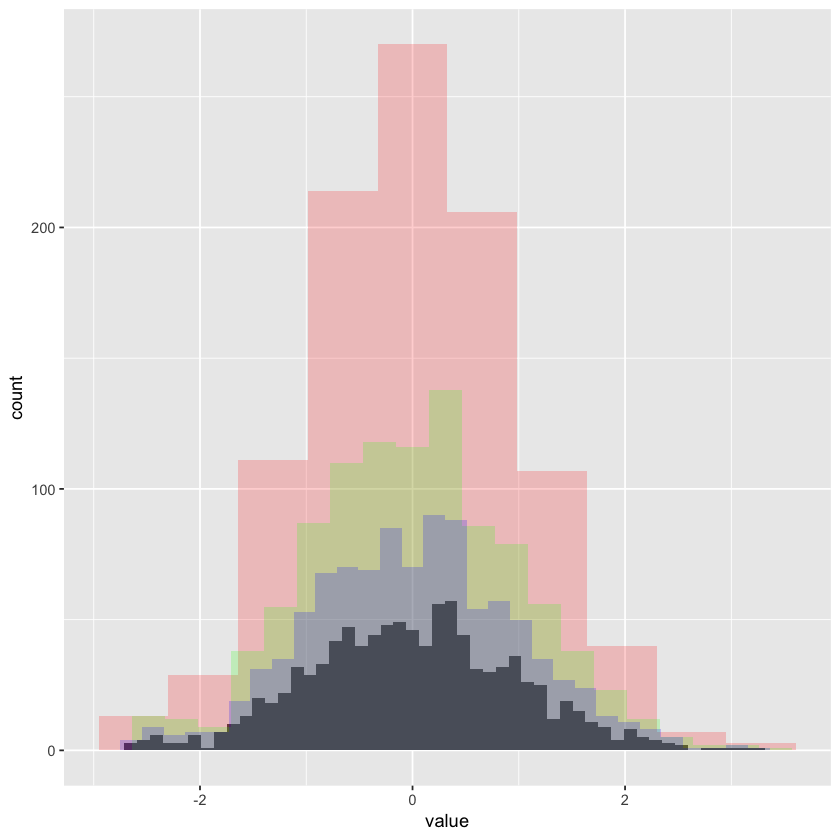

In [11]:
normal_data_ggformat %>% #Plot normal_data
ggplot(aes(x=value))+ #Selects data column by name
geom_histogram(bins=50)+ #Bin 10
geom_histogram(data=normal_data_ggformat, bins =10, fill = "red", alpha = 0.2)+ #Plot sample data
geom_histogram(data=normal_data_ggformat, bins =20, fill = "green", alpha = 0.2)+ #Plot sample data
geom_histogram(data=normal_data_ggformat, bins =30, fill = "blue", alpha = 0.2) #Plot sample data

<a id='Section_3'></a>

# 3. Describing distributions

## 3.1 Peaks modes

### 3.1.1 Bimodal

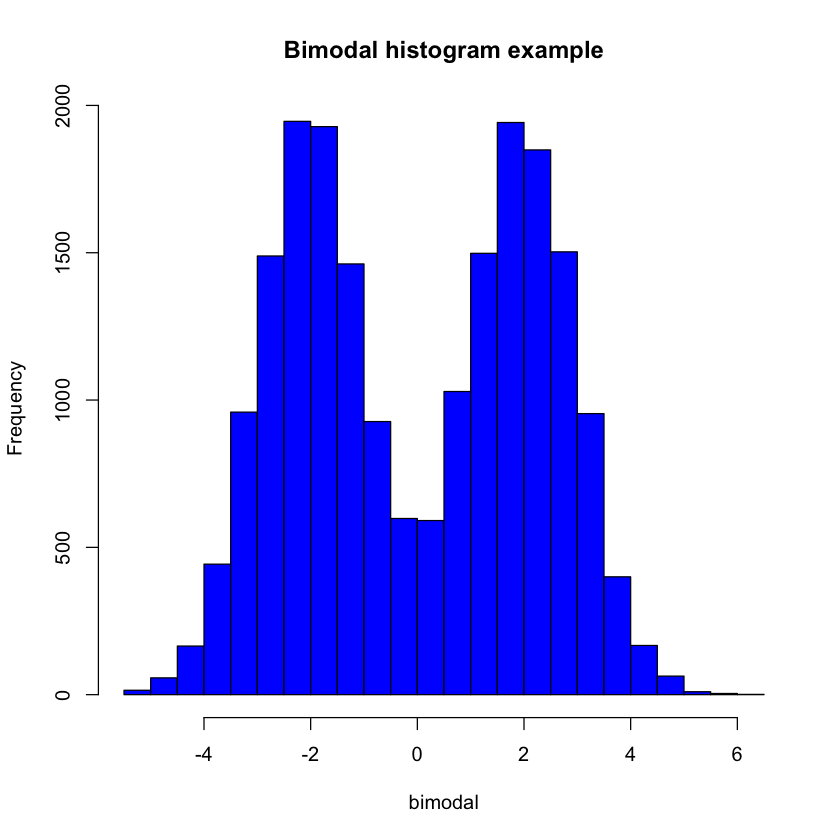

In [12]:
bimodal = c(rnorm(10000, mean = -2, sd = 1), rnorm(10000, mean = 2, sd = 1)) 
hist(
    bimodal,#Data
    col='blue', #Color
    breaks=40, #Bins
    main='Bimodal histogram example'
)

### 3.1.2 Trimodal

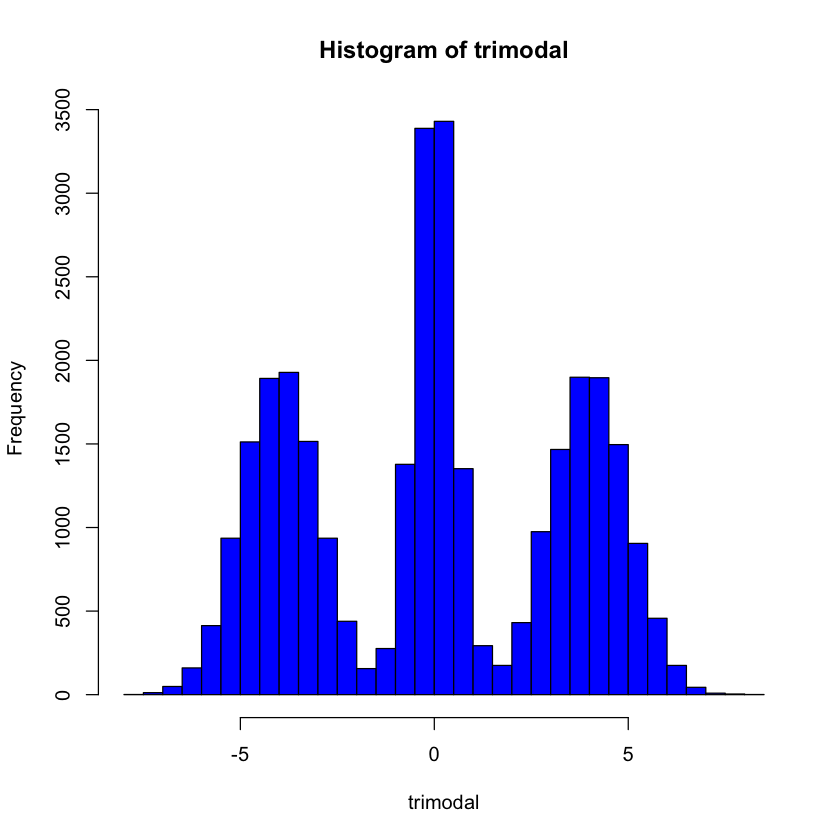

In [13]:
trimodal = c(rnorm(10000, mean = -4, sd = 1),rnorm(10000, mean = 0, sd = .5), rnorm(10000, mean = 4, sd = 1)) 
hist(
    trimodal,#Data
    col='blue', #Color
    breaks=40 #Bins
)

## 3.2 Skew

In [14]:
library(gapminder)
gapminder %>% head(2)

country,continent,year,lifeExp,pop,gdpPercap
Afghanistan,Asia,1952,28.801,8425333,779.4453
Afghanistan,Asia,1957,30.332,9240934,820.8530


In [15]:
mean_life = mean(gapminder$lifeExp)
median_life = median(gapminder$lifeExp)

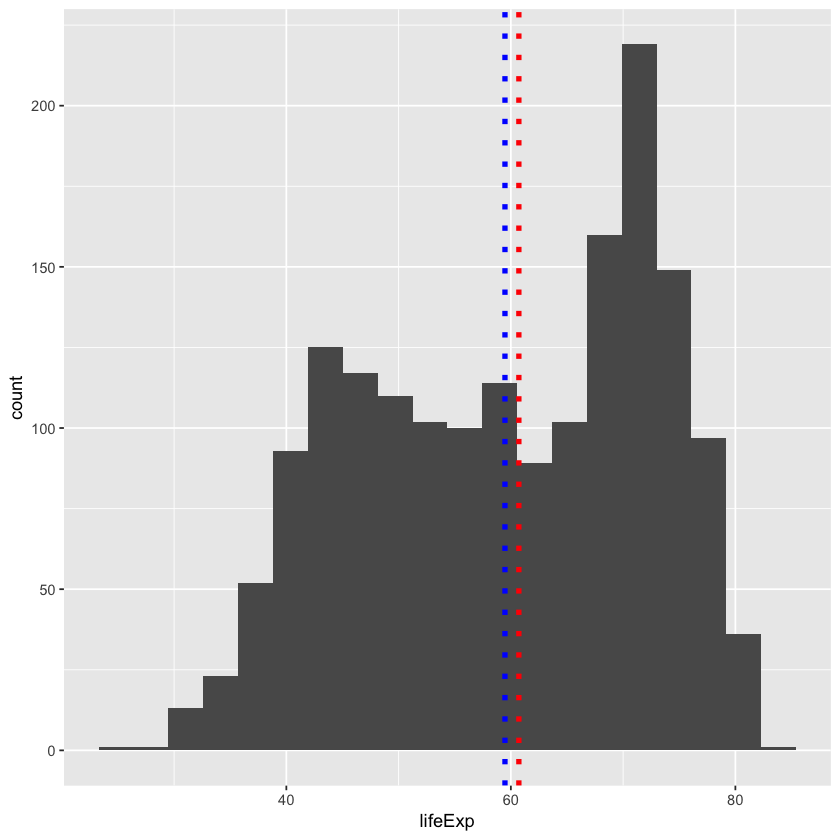

In [16]:
gapminder  %>% #Plot normal_data
ggplot(aes(x=lifeExp))+ #Selects data column by name
geom_histogram(bins=20)+ 
geom_vline(xintercept =mean_life , linetype="dotted", color = "blue", size=1.5, show.legend=TRUE)+
geom_vline(xintercept =median_life , linetype="dotted", color = "red", size=1.5, show.legend=TRUE)

### 3.3 Measuring spread

### 3.3.1 Calculate the interquartile range 


In [17]:
# Select Asian countries in 2007 data 
asia_data = gapminder %>% filter(year==2007&continent=='Asia')  %>% select(lifeExp)

In [18]:
# Calculate IQR
IQR(asia_data$lifeExp)

[1] 10.152

### 3.3.2 Plot boxplot

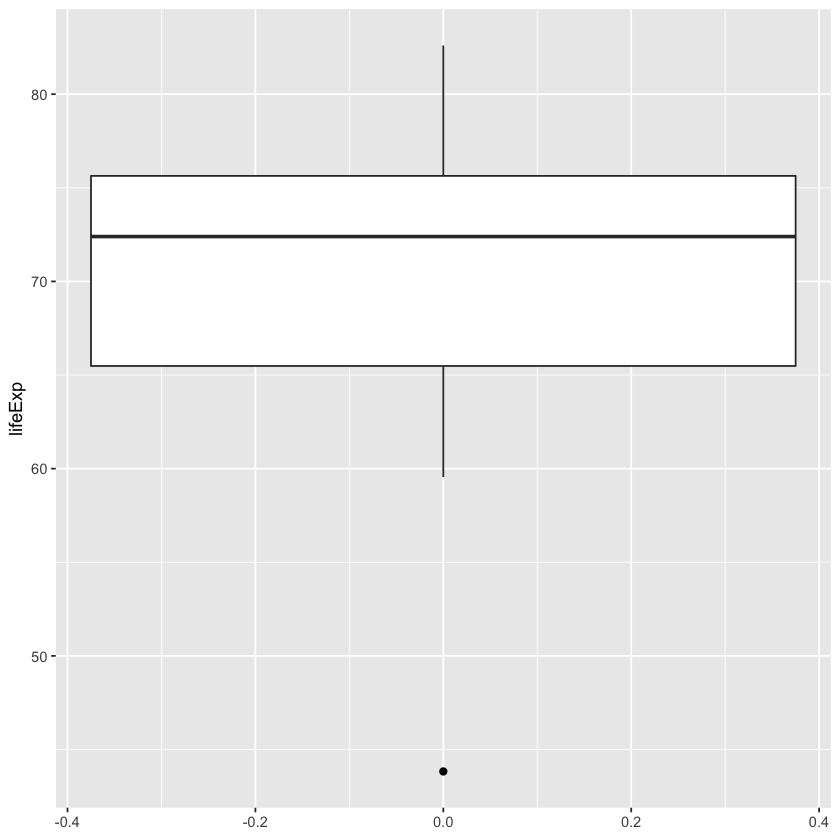

In [19]:
asia_data %>% 
ggplot(aes(y=lifeExp)) + 
geom_boxplot(outlier.colour="black", outlier.shape=16,outlier.size=2)